In [7]:
import numpy as np 
import pandas as pd


from sqlalchemy import create_engine

import warnings
warnings.filterwarnings("ignore")


In [19]:
# 1. Given a CSV file containing Zomato restaurant ratings, use pandas to detect outliers in the 
# 'user_rating' column using the IQR method and print the indices of the detected outliers.

restaurant = pd.read_csv('C:/Users/LENOVO/Downloads/swiggy_orders.csv')
restaurant['rating'].fillna(restaurant['rating'].median(),inplace=True)


q1 = restaurant['rating'].quantile(0.25)
q2 = restaurant['rating'].quantile(0.50)
q3 = restaurant['rating'].quantile(0.75)


Iqr = q3 - q1
print("Iqr is := ",Iqr)

UpperFence = q3 + (Iqr*1.5)
print("UpperFence is := ",UpperFence)
LowerFence = q1 - (Iqr * 1.5)
print("LowerFence is :=",LowerFence)


outliers = restaurant[(restaurant['rating']<LowerFence) | (restaurant['rating']>UpperFence)]
outliers



Iqr is :=  1.0
UpperFence is :=  6.0
LowerFence is := 2.0


,order_id,customer_name,restaurant_name,city,order_amount,payment_method,delivery_time_mins,rating,order_date
11,ORD1011,Customer_12,Pizza Hut,Delhi,505.21,Cash on Delivery,37,1.0,2024-01-04
13,ORD1013,Customer_14,Sagar Ratna,Hyderabad,314.78,Cash on Delivery,40,1.0,2024-01-04
37,ORD1037,Customer_38,Domino's Pizza,Ahmedabad,480.05,Debit Card,32,1.0,2024-01-11
123,ORD1123,Customer_124,Wow Momo,Bangalore,538.39,Cash on Delivery,25,1.0,2024-02-05
132,ORD1132,Customer_133,Pizza Hut,Bangalore,192.30,UPI,17,1.0,2024-02-08
165,ORD1165,Customer_166,Burger King,Ahmedabad,126.06,Wallet,45,1.0,2024-02-18
166,ORD1166,Customer_167,Wow Momo,Bangalore,40.00,Cash on Delivery,41,1.0,2024-02-18


{'whiskers': [<matplotlib.lines.Line2D at 0x23283309be0>,
 'caps': [<matplotlib.lines.Line2D at 0x23283309e80>,
 'boxes': [<matplotlib.lines.Line2D at 0x23283309a90>],
 'medians': [<matplotlib.lines.Line2D at 0x2328330a120>],
 'fliers': [<matplotlib.lines.Line2D at 0x2328330a270>],
 'means': []}

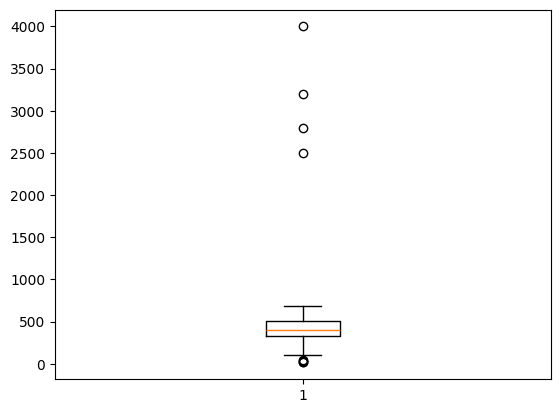

In [21]:
# 2. Create a boxplot for the 'order_amount' column from a Swiggy orders dataset using matplotlib, 
# and visually identify any outliers present.<br><br><em><strong>Hint:</strong> Use plt.boxplot()
# and label your axes for clarity.</em>


import matplotlib.pyplot as plt 


plt.boxplot(restaurant['order_amount'])

In [22]:
# 3.# Apply winsorization to the 'transaction_amount' column in a Paytm transactions DataFrame to cap 
# all values above the 95th percentile and below the 5th percentile, then display the updated column 
# statistics.

lower = restaurant['order_amount'].quantile(0.5)
upper = restaurant['order_amount'].quantile(0.95)

restaurant['order_amount'].clip(lower = lower , upper = upper)


0      405.79
1      424.91
2      506.20
3      405.79
4      405.79
        ...  
195    405.79
196    426.19
197    509.27
198    526.64
199    478.44
Name: order_amount, Length: 200, dtype: float64

In [48]:
# 4. You have a DataFrame of Flipkart product prices stored as strings with currency symbols 
# (e.g., '₹1,299'). Convert this column to numeric type using pandas, ensuring all non-numeric 
# characters are removed.<br><br><em><strong>Hint:</strong> Use str.replace() and astype().</em>

flipkart_data = pd.read_csv("C:/Users/LENOVO/Downloads/flipkart_products.csv")

flipkart_data['price'] = flipkart_data['price'].str.replace("₹","").str.replace(",","").astype(int)
flipkart_data


,product_id,product_name,category,price,discount_percent,rating
0,FLPKT2000,Samsung Galaxy M14 5G,Laptops,62114,43,2.7
1,FLPKT2001,Redmi Note 13 Pro,Mobiles,59063,1,2.8
2,FLPKT2002,Samsung Galaxy M14 5G,Laptops,50188,46,4.2
3,FLPKT2003,Sony WH-CH520 Headphones,Mobiles,11241,51,3.6
4,FLPKT2004,Mi Smart Band 8,Audio,53958,27,3.5
...,...,...,...,...,...,...
145,FLPKT2145,Samsung Galaxy M14 5G,Laptops,11730,14,3.2
146,FLPKT2146,Realme Narzo 60,Laptops,70176,16,4.7
147,FLPKT2147,Mi Smart Band 8,Audio,80283,5,3.5
148,FLPKT2148,Samsung Galaxy Tab A9,Audio,13262,39,4.9


In [53]:
spotify = pd.read_csv("c:/Users/LENOVO/Downloads/spotify_users.csv")
spotify

,user_id,username,country,plan_type,is_premium,listening_hours_per_week,songs_liked,signup_date
0,SPT3000,Krishna_Iyer773,Germany,Free,True,32.2,986,2022-01-01
1,SPT3001,Kiara_Sharma121,UK,Free,Yes,7.1,105,2022-01-10
2,SPT3002,Sai_Patel512,Japan,Family,True,20.5,655,2022-01-19
3,SPT3003,Riya_Iyer623,Canada,Free,1,9.4,1429,2022-01-28
4,SPT3004,Isha_Singh766,India,Family,yes,54.4,463,2022-02-06
...,...,...,...,...,...,...,...,...
115,SPT3115,Arjun_Gupta49,India,Family,1,21.8,1655,2024-11-01
116,SPT3116,Diya_Singh651,Germany,Premium,True,58.4,1530,2024-11-10
117,SPT3117,Vivaan_Verma956,Germany,Premium,0,44.6,452,2024-11-19
118,SPT3118,Krishna_Singh246,Australia,Free,FALSE,54.5,1156,2024-11-28


In [58]:
# 5.Fix the following code snippet where the 'is_premium' column in a Spotify user DataFrame is a mix of 
# boolean, string, and integer types. Convert the entire column to boolean type, treating 'True', 1, and 
# 'yes' as True, and everything else as False.

spotify = pd.read_csv("c:/Users/LENOVO/Downloads/spotify_users.csv")

def filter_bool(value):
    if value == 'True' or value == 'yes' or value == 1:
        return True
    else:
        return False

spotify['is_premium']=spotify['is_premium'].apply(filter_bool)

spotify['is_premium']

0      False
1      False
2       True
3      False
4       True
       ...  
115    False
116    False
117    False
118     True
119    False
Name: is_premium, Length: 120, dtype: bool